# Bilingual Hate Speech Detection — DynamicFusionNet
### Proposed Architecture: BERT + XLM-R + DeBERTa Dynamic Fusion (Teacher) → Knowledge-Distilled BERT (Student)
### Cross-Dataset Generalization Study + Baselines + Full Result Analysis

**Train set (in-domain):** `spelling_correct_with_removeNumber` (primary, bilingual, cleaned)
**Test set (cross-dataset, out-of-domain):** `labeled_data.csv` (Davidson et al. hate-speech tweets — filtered to `tweet` + `hate_speech`)

This notebook trains the proposed model **only on the primary dataset**, then evaluates
**cross-dataset generalization** on the secondary dataset, compares against single-encoder
baselines (XLM-R, RoBERTa, DeBERTa), and runs the full statistical / explainability result
analysis required for an *Expert Systems With Applications* submission.

> **Resume-safe by design:** every training loop (teacher, student, and each baseline) checkpoints
> model + optimizer + scheduler + metric history to `/kaggle/working/checkpoints/` **after every
> epoch**. Re-running any training cell will automatically pick up from the last completed epoch
> instead of starting over. If you start a brand-new Kaggle session (Save & Run All from scratch),
> attach the previous run's **Output** as an input dataset so `/kaggle/working/checkpoints/` is
> repopulated before you run the cells again — otherwise Kaggle gives you a clean `/kaggle/working`.

In [1]:
# ============================================================
# Global Setup — imports, seeds, device, style
# ============================================================
import os, gc, json, time, math, random, warnings
warnings.filterwarnings('ignore')
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score,
                              f1_score, precision_score, recall_score, accuracy_score)
from scipy.stats import ttest_rel, chi2
from scipy.ndimage import gaussian_filter1d

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from tqdm import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
FIGURE_DIR     = "/kaggle/working/figures"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

MAX_LEN    = 128
BATCH_SIZE = 32

# ------------------------------------------------------------
# 2026-style visual identity — shared across every figure
# ------------------------------------------------------------
rcParams['font.family']      = 'DejaVu Sans'
rcParams['font.size']        = 11
rcParams['figure.dpi']       = 130
rcParams['axes.edgecolor']   = '#94A3B8'
rcParams['axes.linewidth']   = 0.9

PALETTE = {
    'primary'   : '#2563EB',   # blue        -> Proposed / Teacher
    'secondary' : '#7C3AED',   # violet      -> Student (KD)
    'accent'    : '#059669',   # emerald     -> positive / correct
    'danger'    : '#DC2626',   # red         -> negative / wrong
    'amber'     : '#D97706',   # amber       -> XLM-R baseline
    'rose'      : '#E11D48',   # rose        -> RoBERTa baseline
    'teal'      : '#0D9488',   # teal        -> DeBERTa baseline
    'dark'      : '#1E293B',
    'grid'      : '#CBD5E1',
    'bg'        : '#F8FAFC',
}

MODEL_COLORS = {
    'Proposed (DynamicFusionNet)' : PALETTE['primary'],
    'Student (KD-BERT)'           : PALETTE['secondary'],
    'XLM-R (baseline)'            : PALETTE['amber'],
    'RoBERTa (baseline)'          : PALETTE['rose'],
    'DeBERTa (baseline)'          : PALETTE['teal'],
}

def style_axes(ax, title=None, xlabel=None, ylabel=None):
    """Shared, modern axis styling used by every plot in this notebook."""
    ax.set_facecolor(PALETTE['bg'])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(PALETTE['grid'])
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title, fontsize=13, fontweight='bold', color=PALETTE['dark'], pad=12)
    if xlabel: ax.set_xlabel(xlabel, fontsize=11, fontweight='bold', color=PALETTE['dark'])
    if ylabel: ax.set_ylabel(ylabel, fontsize=11, fontweight='bold', color=PALETTE['dark'])
    return ax

def savefig(fig, name):
    fig.savefig(os.path.join(FIGURE_DIR, f"{name}.png"), dpi=300, bbox_inches='tight', facecolor='white')

def gradient_bars(ax, x, heights, cmap_name='Blues', width=0.6, zorder=3):
    """Bars with a vertical gradient fill — used to break away from flat-color 2019-style bars."""
    cmap = plt.get_cmap(cmap_name)
    for xi, h in zip(x, heights):
        grad = np.linspace(0.35, 0.95, 256).reshape(-1, 1)
        ax.imshow(grad, extent=[xi - width/2, xi + width/2, 0, h], origin='lower',
                  aspect='auto', cmap=cmap, zorder=zorder, alpha=0.95)
    ax.set_xlim(min(x) - 0.6, max(x) + 0.6)
    ax.set_ylim(0, max(heights) * 1.18)

print("Setup complete.")

Device: cuda
GPU: Tesla T4
Setup complete.


## 1. Resume-Safe Checkpointing

Every model in this notebook (teacher, student, and the 3 baselines) is trained through the
**same** `run_training_loop` function below. It:

1. Looks for a checkpoint for that specific model in `/kaggle/working/checkpoints/`.
2. If found, restores model / optimizer / scheduler / metric history and **continues from the
   next epoch** — it never restarts from epoch 0 unless no checkpoint exists.
3. Saves a checkpoint **after every single epoch**, plus the single best-validation-accuracy
   weights separately, so you always keep the best model even if a later epoch overfits.

In [2]:
# ============================================================
# Checkpoint utilities
# ============================================================
def save_checkpoint(state, path):
    tmp = path + ".tmp"
    torch.save(state, tmp)
    os.replace(tmp, path)

def load_checkpoint(path, map_location):
    if os.path.exists(path):
        try:
            return torch.load(path, map_location=map_location)
        except Exception as e:
            print(f"  [warn] could not load checkpoint at {path}: {e}")
    return None

def run_training_loop(model_name, model, optimizer, scheduler, train_loader, val_loader,
                       train_step_fn, val_step_fn, epochs, patience, ckpt_path, best_path):
    """
    Generic, resume-safe training loop shared by every model in this notebook.

    train_step_fn(model, batch) -> (loss_tensor, preds_np, labels_np)
    val_step_fn(model, batch)   -> (preds_np, labels_np, probs_np, loss_value_float)
    """
    start_epoch = 0
    train_acc_hist, val_acc_hist   = [], []
    train_loss_hist, val_loss_hist = [], []
    best_val_acc, patience_ctr     = 0.0, 0

    ckpt = load_checkpoint(ckpt_path, device)
    if ckpt is not None:
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        if scheduler is not None and ckpt.get("scheduler_state") is not None:
            scheduler.load_state_dict(ckpt["scheduler_state"])
        start_epoch     = ckpt["epoch"] + 1
        train_acc_hist  = ckpt["train_acc_hist"];  val_acc_hist  = ckpt["val_acc_hist"]
        train_loss_hist = ckpt["train_loss_hist"]; val_loss_hist = ckpt["val_loss_hist"]
        best_val_acc    = ckpt["best_val_acc"];    patience_ctr  = ckpt["patience_ctr"]
        print(f"[{model_name}] Resuming from epoch {start_epoch+1}/{epochs} "
              f"(best val so far: {best_val_acc:.4f})")
    else:
        print(f"[{model_name}] No checkpoint found — starting fresh training.")

    if start_epoch >= epochs:
        print(f"[{model_name}] Already completed {epochs} epochs — skipping training.")

    for epoch in range(start_epoch, epochs):
        model.train()
        correct = total = 0
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"[{model_name}] Epoch {epoch+1}/{epochs} [Train]"):
            loss, preds, labels = train_step_fn(model, batch)
            correct      += int((preds == labels).sum())
            total        += len(labels)
            running_loss += float(loss) * len(labels)
        train_acc  = correct / total
        train_loss = running_loss / total
        train_acc_hist.append(train_acc); train_loss_hist.append(train_loss)

        model.eval()
        v_true, v_pred, v_prob = [], [], []
        v_loss_sum, v_count = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                preds, labels, probs, loss_val = val_step_fn(model, batch)
                v_true.extend(labels); v_pred.extend(preds); v_prob.extend(probs)
                v_loss_sum += loss_val * len(labels); v_count += len(labels)
        v_true = np.array(v_true); v_pred = np.array(v_pred); v_prob = np.array(v_prob)
        val_acc  = (v_true == v_pred).mean()
        val_loss = v_loss_sum / v_count
        val_acc_hist.append(val_acc); val_loss_hist.append(val_loss)

        gap = (train_acc - val_acc) * 100
        print(f"[{model_name}] Epoch {epoch+1}/{epochs} | "
              f"Train Acc {train_acc:.4f} Loss {train_loss:.4f} | "
              f"Val Acc {val_acc:.4f} Loss {val_loss:.4f} | Gap {gap:.1f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc; patience_ctr = 0
            torch.save(model.state_dict(), best_path)
            print(f"   -> [{model_name}] new best saved ({best_val_acc:.4f})")
        else:
            patience_ctr += 1
            print(f"   -> [{model_name}] patience {patience_ctr}/{patience}")

        save_checkpoint({
            "epoch": epoch, "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
            "train_acc_hist": train_acc_hist, "val_acc_hist": val_acc_hist,
            "train_loss_hist": train_loss_hist, "val_loss_hist": val_loss_hist,
            "best_val_acc": best_val_acc, "patience_ctr": patience_ctr,
        }, ckpt_path)

        if patience_ctr >= patience:
            print(f"[{model_name}] Early stopping triggered at epoch {epoch+1}.")
            break

    if os.path.exists(best_path):
        model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()
    return {"train_acc": train_acc_hist, "val_acc": val_acc_hist,
            "train_loss": train_loss_hist, "val_loss": val_loss_hist,
            "best_val_acc": best_val_acc}

print("Checkpoint utilities + run_training_loop ready.")

Checkpoint utilities + run_training_loop ready.


## 2. Datasets

- **Primary dataset (in-domain train/val):** `spelling_correct_with_removeNumber` — already
  spelling-corrected and number-stripped. Columns: `sentence`, `labels` (0 = Non-Hate, 1 = Hate).
- **Secondary dataset (cross-dataset test, out-of-domain):** `labeled_data.csv` (Davidson et al.).
  Per your instruction, we keep **only `tweet` and `hate_speech`** and drop every other column
  (`count`, `offensive_language`, `neither`, `class`, `Unnamed: 0`).

> **Important labeling note:** in the Davidson dataset, `hate_speech` is **not** a binary label —
> it is the *number of CrowdFlower annotators (0–7)* who tagged that tweet as hate speech. Since
> our primary dataset (and the proposed model) is trained for **binary** classification, we
> binarize it: `label = 1` if **at least one** annotator flagged it as hate speech, else `0`. This
> keeps the column you asked for while making it usable as a binary cross-dataset test label.
> If you'd rather use the dataset's own majority-vote `class` column instead, change the
> `BINARIZE_RULE` flag below.

In [3]:
# ============================================================
# Load + clean datasets
# ============================================================
# >>> EDIT THESE TWO PATHS to match your Kaggle "Add Input" dataset paths <<<
PRIMARY_PATH   = "/kaggle/input/datasets/sanjidakhanom3701/monolingual-hate-speech/spelling_correct_with_removeNumber - spelling_correct_with_removeNumber.csv"
SECONDARY_PATH = "/kaggle/input/datasets/sanjidakhanom3701/english-dataset/labeled_data.csv"

BINARIZE_RULE = "any_annotator"   # "any_annotator" -> hate_speech>0 is 1 ; "majority" -> hate_speech >= count/2

# ---- Primary (training) dataset ----
df_train_raw = pd.read_csv(PRIMARY_PATH)
df_train_raw.columns = ["text", "label"]
df_train_raw = df_train_raw.dropna(subset=["text", "label"]).reset_index(drop=True)
df_train_raw["text"]  = df_train_raw["text"].astype(str)
df_train_raw["label"] = df_train_raw["label"].astype(int)
df_train = df_train_raw

# ---- Secondary (cross-dataset test) dataset ----
df_test_full = pd.read_csv(SECONDARY_PATH)
df_test_sel  = df_test_full[["tweet", "hate_speech"]].copy()     # keep ONLY these two columns
df_test_sel.columns = ["text", "label"]
df_test_sel["text"] = df_test_sel["text"].astype(str)

if BINARIZE_RULE == "any_annotator":
    df_test_sel["label"] = (df_test_sel["label"] > 0).astype(int)
else:
    df_test_sel["label"] = (df_test_sel["label"] >= (df_test_full["count"] / 2)).astype(int)

df_test = df_test_sel.dropna(subset=["text", "label"]).reset_index(drop=True)

num_classes = 2

print("="*64)
print("DATASET CLASS DISTRIBUTIONS")
print("="*64)
print("\n[Primary]  spelling_correct_with_removeNumber  (in-domain train/val)")
print(f"Total samples: {len(df_train)}")
print(df_train['label'].value_counts().rename({0: 'Non-Hate (0)', 1: 'Hate (1)'}))

print("\n[Secondary] labeled_data.csv -> tweet + hate_speech (binarized)  (cross-dataset test)")
print(f"Total samples: {len(df_test)}")
print(df_test['label'].value_counts().rename({0: 'Non-Hate (0)', 1: 'Hate (1)'}))

DATASET CLASS DISTRIBUTIONS

[Primary]  spelling_correct_with_removeNumber  (in-domain train/val)
Total samples: 25570
label
Hate (1)        14565
Non-Hate (0)    11005
Name: count, dtype: int64

[Secondary] labeled_data.csv -> tweet + hate_speech (binarized)  (cross-dataset test)
Total samples: 24783
label
Non-Hate (0)    19790
Hate (1)         4993
Name: count, dtype: int64


## 3. Dataset Health / Distribution Figures

Class balance + text-length distributions for both datasets — useful for the paper's "dataset
characteristics" subsection and to visually justify class-weighting / focal loss choices.

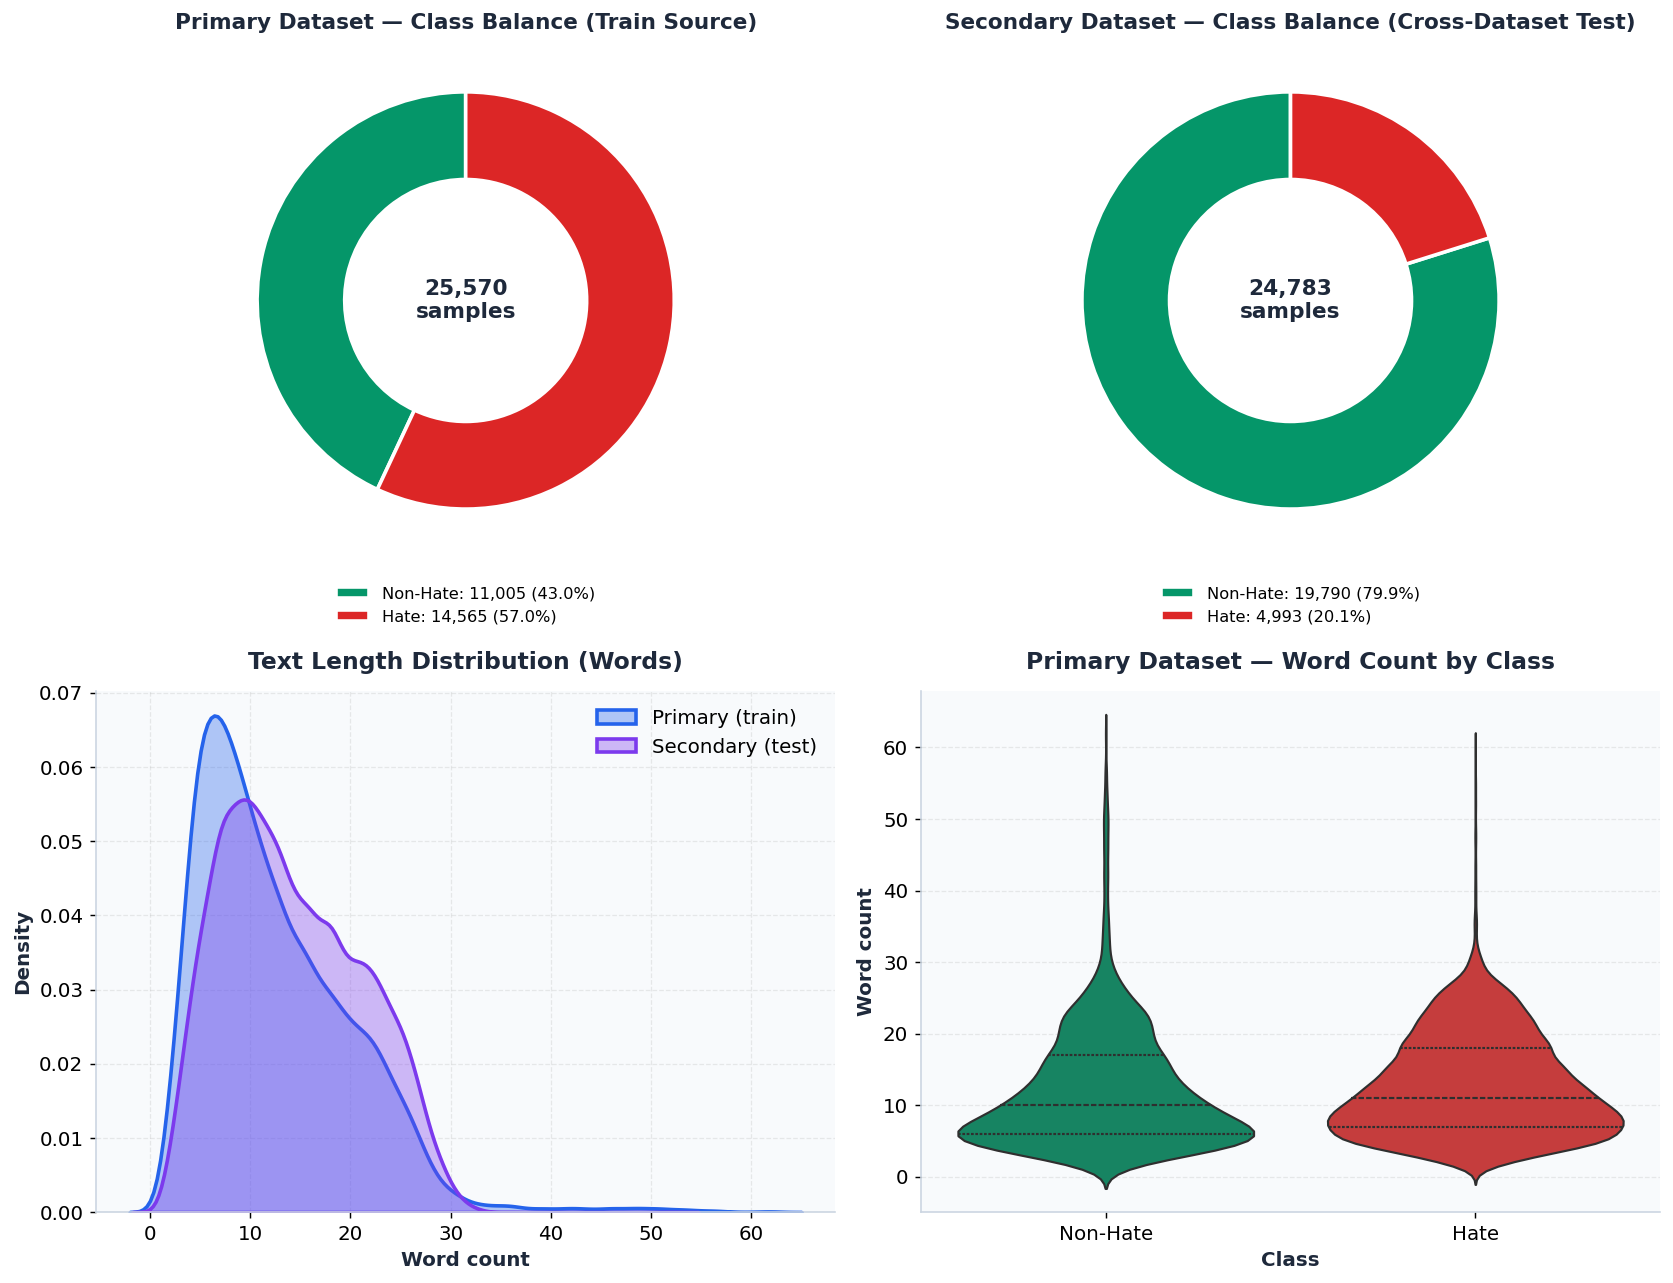

In [4]:
# ============================================================
# Dataset distribution dashboard (donut charts + length distributions)
# ============================================================
def word_count(s):
    return len(str(s).split())

df_train['word_count'] = df_train['text'].apply(word_count)
df_test['word_count']  = df_test['text'].apply(word_count)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Donut: Primary class balance ---
ax = axes[0, 0]
vals = df_train['label'].value_counts().sort_index()
colors = [PALETTE['accent'], PALETTE['danger']]
wedges, _ = ax.pie(vals, colors=colors, startangle=90, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
ax.text(0, 0, f"{len(df_train):,}\nsamples", ha='center', va='center', fontsize=12, fontweight='bold', color=PALETTE['dark'])
ax.legend(wedges, [f"Non-Hate: {vals[0]:,} ({vals[0]/len(df_train)*100:.1f}%)",
                    f"Hate: {vals[1]:,} ({vals[1]/len(df_train)*100:.1f}%)"],
          loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
ax.set_title("Primary Dataset — Class Balance (Train Source)", fontsize=12, fontweight='bold', color=PALETTE['dark'])

# --- Donut: Secondary class balance ---
ax = axes[0, 1]
vals2 = df_test['label'].value_counts().sort_index()
wedges, _ = ax.pie(vals2, colors=colors, startangle=90, wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
ax.text(0, 0, f"{len(df_test):,}\nsamples", ha='center', va='center', fontsize=12, fontweight='bold', color=PALETTE['dark'])
ax.legend(wedges, [f"Non-Hate: {vals2[0]:,} ({vals2[0]/len(df_test)*100:.1f}%)",
                    f"Hate: {vals2[1]:,} ({vals2[1]/len(df_test)*100:.1f}%)"],
          loc='upper center', bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=False)
ax.set_title("Secondary Dataset — Class Balance (Cross-Dataset Test)", fontsize=12, fontweight='bold', color=PALETTE['dark'])

# --- Word-count distribution overlay ---
ax = axes[1, 0]
style_axes(ax, "Text Length Distribution (Words)", "Word count", "Density")
sns.kdeplot(df_train['word_count'], ax=ax, color=PALETTE['primary'], fill=True, alpha=0.35, lw=2, label='Primary (train)')
sns.kdeplot(df_test['word_count'],  ax=ax, color=PALETTE['secondary'], fill=True, alpha=0.35, lw=2, label='Secondary (test)')
ax.legend(frameon=False)

# --- Class-wise word count (violin) for primary ---
ax = axes[1, 1]
style_axes(ax, "Primary Dataset — Word Count by Class", "Class", "Word count")
plot_df = df_train.copy(); plot_df['Class'] = plot_df['label'].map({0: 'Non-Hate', 1: 'Hate'})
sns.violinplot(data=plot_df, x='Class', y='word_count', ax=ax,
               palette=[PALETTE['accent'], PALETTE['danger']], inner='quartile', linewidth=1.2)

plt.tight_layout()
savefig(fig, "dataset_distribution_dashboard")
plt.show()

## 4. Proposed Architecture — Data Preparation

The teacher (`DynamicFusionNet`) needs **three** parallel tokenizations (BERT, XLM-R, DeBERTa)
per sample; the student and every single-encoder baseline only need one. Both dataset classes
are defined once and reused everywhere.

In [5]:
# ============================================================
# Tokenizers, Dataset classes, train/val split, class weights
# ============================================================
bert_tokenizer    = AutoTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer    = AutoTokenizer.from_pretrained("xlm-roberta-base")
deberta_tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")

class EnsembleDataset(Dataset):
    """Triple-tokenized dataset used by the proposed DynamicFusionNet (teacher)."""
    def __init__(self, texts, labels, bert_tok, xlmr_tok, deberta_tok, max_len=128):
        self.texts, self.labels = texts, labels
        self.bert_tok, self.xlmr_tok, self.deberta_tok = bert_tok, xlmr_tok, deberta_tok
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        b = self.bert_tok(text, padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        x = self.xlmr_tok(text, padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        d = self.deberta_tok(text, padding="max_length", truncation=True, max_length=self.max_len, return_tensors="pt")
        return {
            "bert_ids": b["input_ids"].squeeze(0), "bert_mask": b["attention_mask"].squeeze(0),
            "xlmr_ids": x["input_ids"].squeeze(0), "xlmr_mask": x["attention_mask"].squeeze(0),
            "deberta_ids": d["input_ids"].squeeze(0), "deberta_mask": d["attention_mask"].squeeze(0),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

class SingleInputDataset(Dataset):
    """Single-tokenizer dataset reused by the KD student AND every single-encoder baseline."""
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(str(self.texts[idx]), padding="max_length", truncation=True,
                              max_length=self.max_len, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(int(self.labels[idx]), dtype=torch.long)
        }

# Backward-compatible alias
StudentDataset = SingleInputDataset

# ---- Train / Val split (primary dataset only — secondary is held out entirely as test) ----
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train['text'].tolist(), df_train['label'].tolist(),
    test_size=0.2, stratify=df_train['label'].tolist(), random_state=SEED
)
print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Cross-dataset test: {len(df_test)}")

test_texts  = df_test['text'].tolist()
test_labels = df_test['label'].tolist()

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float)
print(f"Class weights: {class_weights}")

# ---- Ensemble (teacher) loaders ----
train_dataset = EnsembleDataset(train_texts, train_labels, bert_tokenizer, xlmr_tokenizer, deberta_tokenizer, MAX_LEN)
val_dataset   = EnsembleDataset(val_texts,   val_labels,   bert_tokenizer, xlmr_tokenizer, deberta_tokenizer, MAX_LEN)
test_dataset_ensemble = EnsembleDataset(test_texts, test_labels, bert_tokenizer, xlmr_tokenizer, deberta_tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader_ensemble = DataLoader(test_dataset_ensemble, batch_size=BATCH_SIZE)

print("Dataset objects + loaders ready.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Train: 20456 | Val: 5114 | Cross-dataset test: 24783
Class weights: tensor([1.1617, 0.8778])
Dataset objects + loaders ready.


## 5. Proposed Architecture — Model Components

`FocalLoss` (class-imbalance compensation) + `SupervisedContrastiveLoss` + a `GradientReversalLayer`
(language-adversarial branch) + the `DynamicFusionNet` teacher itself (BERT + XLM-R + DeBERTa fused
via multi-head attention).

In [6]:
# ============================================================
# Loss functions + GRL + DynamicFusionNet
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__(); self.weight, self.gamma = weight, gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__(); self.temperature = temperature
    def forward(self, features, labels):
        features = F.normalize(features, p=2, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        mask_no_self = mask - torch.eye(labels.shape[0]).to(features.device)
        exp_sim = torch.exp(sim) * (1 - torch.eye(labels.shape[0]).to(features.device))
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
        mask_sum = mask_no_self.sum(dim=1).clamp(min=1)
        return -(mask_no_self * log_prob).sum(dim=1).div(mask_sum).mean()

class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, alpha): ctx.alpha = alpha; return x.view_as(x)
    @staticmethod
    def backward(ctx, grad): return grad.neg() * ctx.alpha, None

class GradientReversalLayer(nn.Module):
    def __init__(self, alpha=1.0): super().__init__(); self.alpha = alpha
    def forward(self, x): return GradientReversalFn.apply(x, self.alpha)

class DynamicFusionNet(nn.Module):
    """Proposed architecture: BERT + XLM-R + DeBERTa fused via multi-head attention,
    with a gradient-reversal language-adversarial branch and supervised contrastive regularization."""
    def __init__(self, num_classes=2, num_languages=2):
        super().__init__()
        self.bert    = AutoModel.from_pretrained("bert-base-uncased")
        self.xlmr    = AutoModel.from_pretrained("xlm-roberta-base")
        self.deberta = AutoModel.from_pretrained("microsoft/deberta-base")

        for base in [self.bert, self.xlmr, self.deberta]:
            for p in base.embeddings.parameters(): p.requires_grad = False
            for layer in base.encoder.layer[:4]:
                for p in layer.parameters(): p.requires_grad = False

        hidden_dim = 768
        self.attention  = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=8, batch_first=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.grl = GradientReversalLayer(alpha=1.0)
        self.lang_classifier = nn.Linear(hidden_dim, num_languages)

    def forward(self, bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask):
        bert_cls = self.bert(input_ids=bert_ids, attention_mask=bert_mask).last_hidden_state[:, 0, :]
        xlmr_cls = self.xlmr(input_ids=xlmr_ids, attention_mask=xlmr_mask).last_hidden_state[:, 0, :]
        deb_cls  = self.deberta(input_ids=deb_ids, attention_mask=deb_mask).last_hidden_state[:, 0, :]
        stacked  = torch.stack((bert_cls, xlmr_cls, deb_cls), dim=1)
        attn_out, _ = self.attention(stacked, stacked, stacked)
        fused = torch.mean(attn_out, dim=1)
        hate_logits = self.classifier(fused)
        lang_logits = self.lang_classifier(self.grl(fused))
        return hate_logits, lang_logits, fused

def compute_ece(probs, labels, n_bins=10):
    confs = np.max(probs, axis=1); preds = np.argmax(probs, axis=1)
    edges = np.linspace(0, 1, n_bins + 1); ece = 0.0; b_acc, b_conf = [], []
    for i in range(n_bins):
        mask = (confs > edges[i]) & (confs <= edges[i + 1])
        if mask.sum() > 0:
            acc, conf = (preds[mask] == labels[mask]).mean(), confs[mask].mean()
            ece += mask.sum() * abs(acc - conf); b_acc.append(acc); b_conf.append(conf)
        else:
            b_acc.append(0); b_conf.append(0)
    return ece / len(labels), np.array(b_acc), np.array(b_conf)

print("Model components ready.")

Model components ready.


## 6. Train the Proposed Model (Teacher — DynamicFusionNet)

Trained **only** on the primary dataset's train split, validated on its val split.
Resumable via `run_training_loop`.

In [7]:
# ============================================================
# Train DynamicFusionNet (teacher / proposed architecture)
# ============================================================
torch.cuda.empty_cache(); gc.collect()
fusion_model = DynamicFusionNet(num_classes=num_classes).to(device)
trainable = sum(p.numel() for p in fusion_model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable/1e6:.1f}M")

focal_criterion = FocalLoss(weight=class_weights.to(device), gamma=2.0)
scl_criterion   = SupervisedContrastiveLoss(temperature=0.1).to(device)
lang_criterion  = nn.CrossEntropyLoss().to(device)
lambda_scl, lambda_grl = 0.05, 0.02

TEACHER_EPOCHS   = 10
TEACHER_PATIENCE = 3
optimizer = torch.optim.AdamW(fusion_model.parameters(), lr=1e-5)
accumulation_steps = 4
total_steps = (len(train_loader) // accumulation_steps) * TEACHER_EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

def teacher_train_step(model, batch):
    bert_ids, bert_mask = batch["bert_ids"].to(device), batch["bert_mask"].to(device)
    xlmr_ids, xlmr_mask = batch["xlmr_ids"].to(device), batch["xlmr_mask"].to(device)
    deb_ids, deb_mask   = batch["deberta_ids"].to(device), batch["deberta_mask"].to(device)
    lb = batch["label"].to(device)
    dummy_lang = torch.randint(0, 2, (lb.size(0),)).to(device)

    hate_logits, lang_logits, fused = model(bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask)
    loss = (focal_criterion(hate_logits, lb)
            + lambda_scl * scl_criterion(fused, lb)
            + lambda_grl * lang_criterion(lang_logits, dummy_lang))
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step(); scheduler.step()
    preds = torch.argmax(hate_logits, dim=1).cpu().numpy()
    return loss.item(), preds, lb.cpu().numpy()

def teacher_val_step(model, batch):
    bert_ids, bert_mask = batch["bert_ids"].to(device), batch["bert_mask"].to(device)
    xlmr_ids, xlmr_mask = batch["xlmr_ids"].to(device), batch["xlmr_mask"].to(device)
    deb_ids, deb_mask   = batch["deberta_ids"].to(device), batch["deberta_mask"].to(device)
    lb = batch["label"].to(device)
    hate_logits, _, _ = model(bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask)
    loss = F.cross_entropy(hate_logits, lb)
    probs = torch.softmax(hate_logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    return preds.cpu().numpy(), lb.cpu().numpy(), probs.cpu().numpy(), loss.item()

teacher_history = run_training_loop(
    "Teacher", fusion_model, optimizer, scheduler, train_loader, val_loader,
    teacher_train_step, teacher_val_step, TEACHER_EPOCHS, TEACHER_PATIENCE,
    ckpt_path=os.path.join(CHECKPOINT_DIR, "teacher_ckpt.pt"),
    best_path=os.path.join(CHECKPOINT_DIR, "teacher_best.pt"),
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[Teacher] Epoch 4/10 | Train Acc 0.8906 Loss 0.2469 | Val Acc 0.8950 Loss 0.3127 | Gap -0.4%
   -> [Teacher] patience 1/3


[Teacher] Epoch 5/10 [Train]: 100%|██████████| 640/640 [18:18<00:00,  1.72s/it]


[Teacher] Epoch 5/10 | Train Acc 0.8917 Loss 0.2469 | Val Acc 0.8940 Loss 0.3111 | Gap -0.2%
   -> [Teacher] patience 2/3


[Teacher] Epoch 6/10 [Train]: 100%|██████████| 640/640 [18:19<00:00,  1.72s/it]


[Teacher] Epoch 6/10 | Train Acc 0.8938 Loss 0.2450 | Val Acc 0.8950 Loss 0.3068 | Gap -0.1%
   -> [Teacher] patience 3/3
[Teacher] Early stopping triggered at epoch 6.


## 7. Teacher — In-Domain Evaluation (Primary Val Split)

Threshold-tuned classification report, ECE / reliability diagram, and the train-vs-val
**training curves** (accuracy + loss).

Teacher final eval [val]: 100%|██████████| 160/160 [01:50<00:00,  1.45it/s]


PROPOSED MODEL (Teacher) — IN-DOMAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Hate       0.88      0.88      0.88      2201
        Hate       0.91      0.91      0.91      2913

    accuracy                           0.89      5114
   macro avg       0.89      0.89      0.89      5114
weighted avg       0.89      0.89      0.89      5114

Best Val Accuracy : 89.54%
Threshold Acc     : 89.50% (t=0.44)
ROC AUC           : 0.9600
ECE               : 0.0992


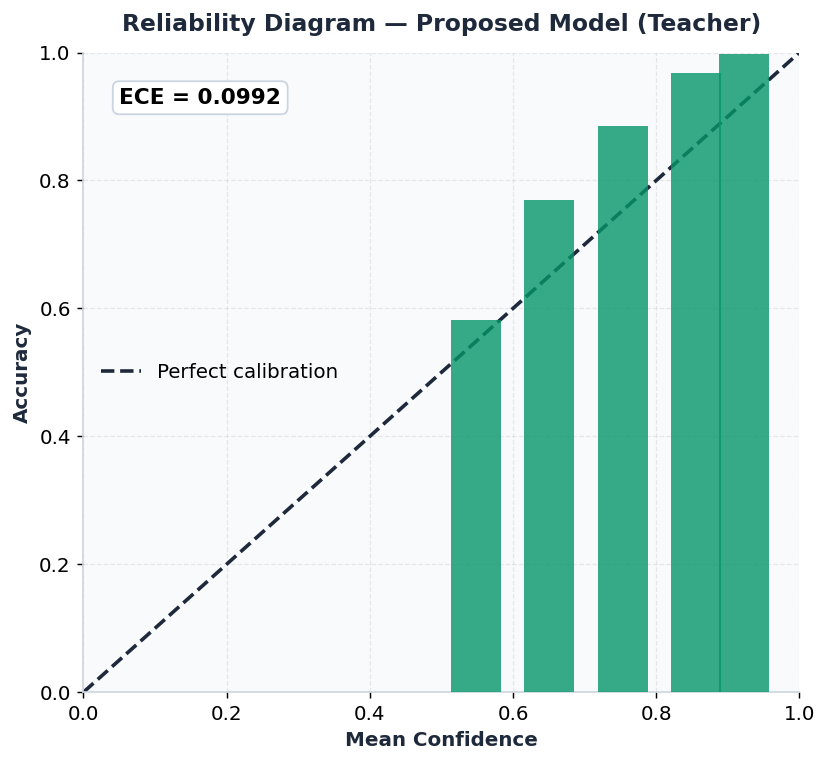

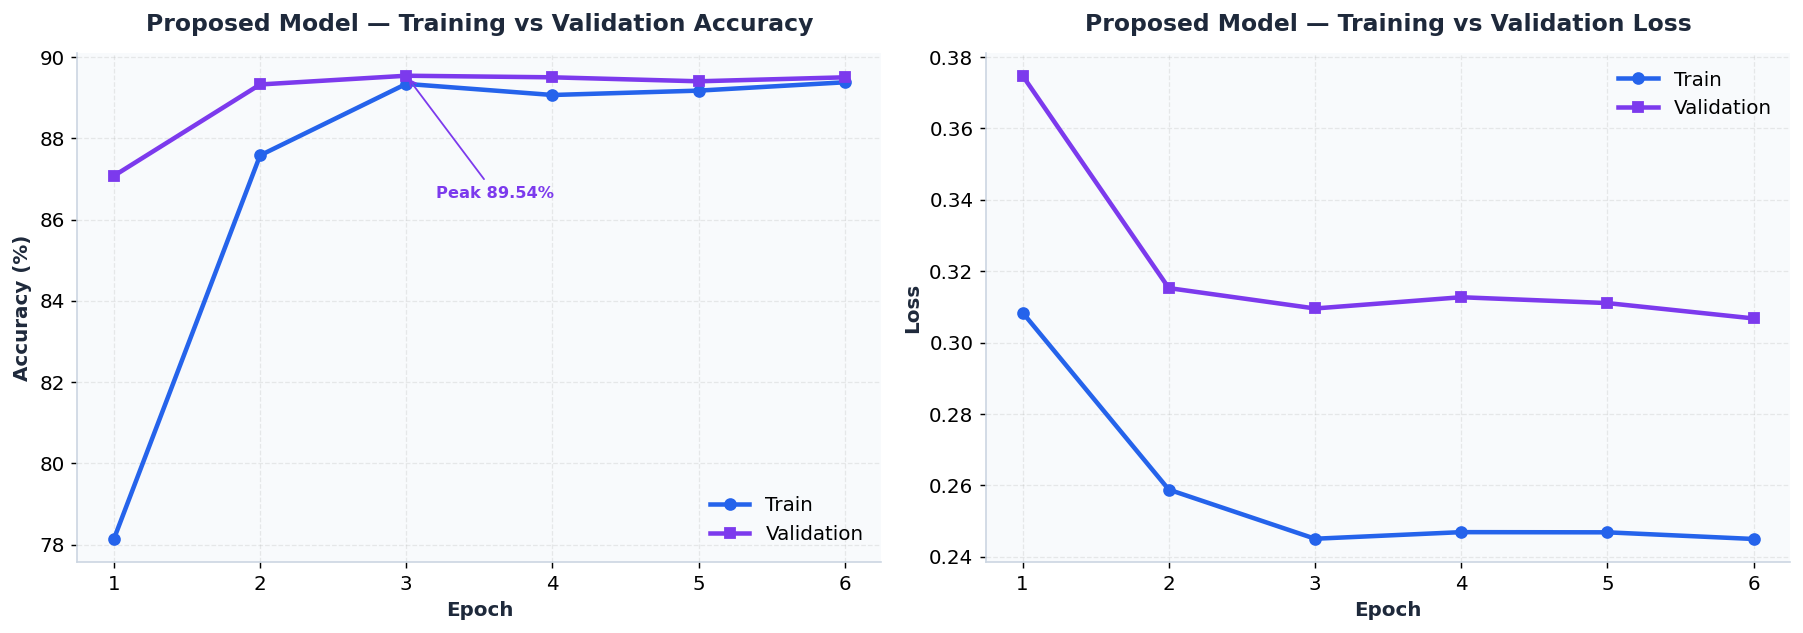

In [8]:
# ============================================================
# Teacher: in-domain (primary val) inference + report + calibration + training curves
# ============================================================
fusion_model.eval()
te_val_true, te_val_pred_raw, te_val_prob, te_val_fused = [], [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Teacher final eval [val]"):
        bert_ids, bert_mask = batch["bert_ids"].to(device), batch["bert_mask"].to(device)
        xlmr_ids, xlmr_mask = batch["xlmr_ids"].to(device), batch["xlmr_mask"].to(device)
        deb_ids, deb_mask   = batch["deberta_ids"].to(device), batch["deberta_mask"].to(device)
        lb = batch["label"].to(device)
        hate_logits, _, fused = fusion_model(bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask)
        probs = torch.softmax(hate_logits, dim=1)
        te_val_true.extend(lb.cpu().numpy()); te_val_prob.extend(probs.cpu().numpy())
        te_val_fused.extend(fused.cpu().numpy())

te_val_true = np.array(te_val_true); te_val_prob = np.array(te_val_prob); te_val_fused = np.array(te_val_fused)
te_best_t = max(np.arange(0.30, 0.70, 0.01), key=lambda t: f1_score(te_val_true, (te_val_prob[:,1] > t).astype(int)))
te_val_pred = (te_val_prob[:, 1] > te_best_t).astype(int)

print("="*60); print("PROPOSED MODEL (Teacher) — IN-DOMAIN CLASSIFICATION REPORT"); print("="*60)
print(classification_report(te_val_true, te_val_pred, target_names=["Non-Hate", "Hate"]))
te_val_auc = roc_auc_score(te_val_true, te_val_prob[:, 1])
print(f"Best Val Accuracy : {teacher_history['best_val_acc']*100:.2f}%")
print(f"Threshold Acc     : {(te_val_true==te_val_pred).mean()*100:.2f}% (t={te_best_t:.2f})")
print(f"ROC AUC           : {te_val_auc:.4f}")

te_ece, te_b_acc, te_b_conf = compute_ece(te_val_prob, te_val_true)
print(f"ECE               : {te_ece:.4f}")

# ---- Reliability diagram ----
fig, ax = plt.subplots(figsize=(6.5, 6))
style_axes(ax, "Reliability Diagram — Proposed Model (Teacher)", "Mean Confidence", "Accuracy")
valid = te_b_conf > 0
for c, a in zip(te_b_conf[valid], te_b_acc[valid]):
    col = PALETTE['danger'] if a < c else PALETTE['accent']
    ax.bar(c, a, width=0.07, alpha=0.8, color=col, zorder=3)
ax.plot([0, 1], [0, 1], '--', color=PALETTE['dark'], lw=2, label='Perfect calibration')
ax.text(0.05, 0.92, f'ECE = {te_ece:.4f}', transform=ax.transAxes, fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=PALETTE['grid']))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(frameon=False)
plt.tight_layout(); savefig(fig, "teacher_reliability_diagram"); plt.show()

# ---- Training curves (accuracy + loss) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = np.arange(1, len(teacher_history['train_acc']) + 1)

ax = axes[0]; style_axes(ax, "Proposed Model — Training vs Validation Accuracy", "Epoch", "Accuracy (%)")
ax.plot(ep, np.array(teacher_history['train_acc'])*100, color=PALETTE['primary'], lw=2.5, marker='o', label='Train')
ax.plot(ep, np.array(teacher_history['val_acc'])*100, color=PALETTE['secondary'], lw=2.5, marker='s', label='Validation')
best_ep = int(np.argmax(teacher_history['val_acc'])) + 1
ax.annotate(f"Peak {teacher_history['val_acc'][best_ep-1]*100:.2f}%", xy=(best_ep, teacher_history['val_acc'][best_ep-1]*100),
            xytext=(best_ep+0.2, teacher_history['val_acc'][best_ep-1]*100-3), fontsize=9, fontweight='bold',
            color=PALETTE['secondary'], arrowprops=dict(arrowstyle='->', color=PALETTE['secondary']))
ax.legend(frameon=False); ax.set_xticks(ep)

ax = axes[1]; style_axes(ax, "Proposed Model — Training vs Validation Loss", "Epoch", "Loss")
ax.plot(ep, teacher_history['train_loss'], color=PALETTE['primary'], lw=2.5, marker='o', label='Train')
ax.plot(ep, teacher_history['val_loss'], color=PALETTE['secondary'], lw=2.5, marker='s', label='Validation')
ax.legend(frameon=False); ax.set_xticks(ep)

plt.tight_layout(); savefig(fig, "teacher_training_curves"); plt.show()

## 8. Teacher — Cross-Dataset Generalization (Secondary Test Set)

This is the **real generalization test**: the model never saw a single sample from this dataset
during training. Includes classification report, confusion matrix, ROC curve, and Precision-Recall
(**"test curve"**).

Teacher cross-dataset inference: 100%|██████████| 775/775 [09:01<00:00,  1.43it/s]


PROPOSED MODEL (Teacher) — CROSS-DATASET CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Hate       0.91      0.19      0.31     19790
        Hate       0.22      0.93      0.36      4993

    accuracy                           0.34     24783
   macro avg       0.57      0.56      0.34     24783
weighted avg       0.77      0.34      0.32     24783

Cross-dataset Accuracy : 33.64%
Cross-dataset ROC AUC  : 0.5057


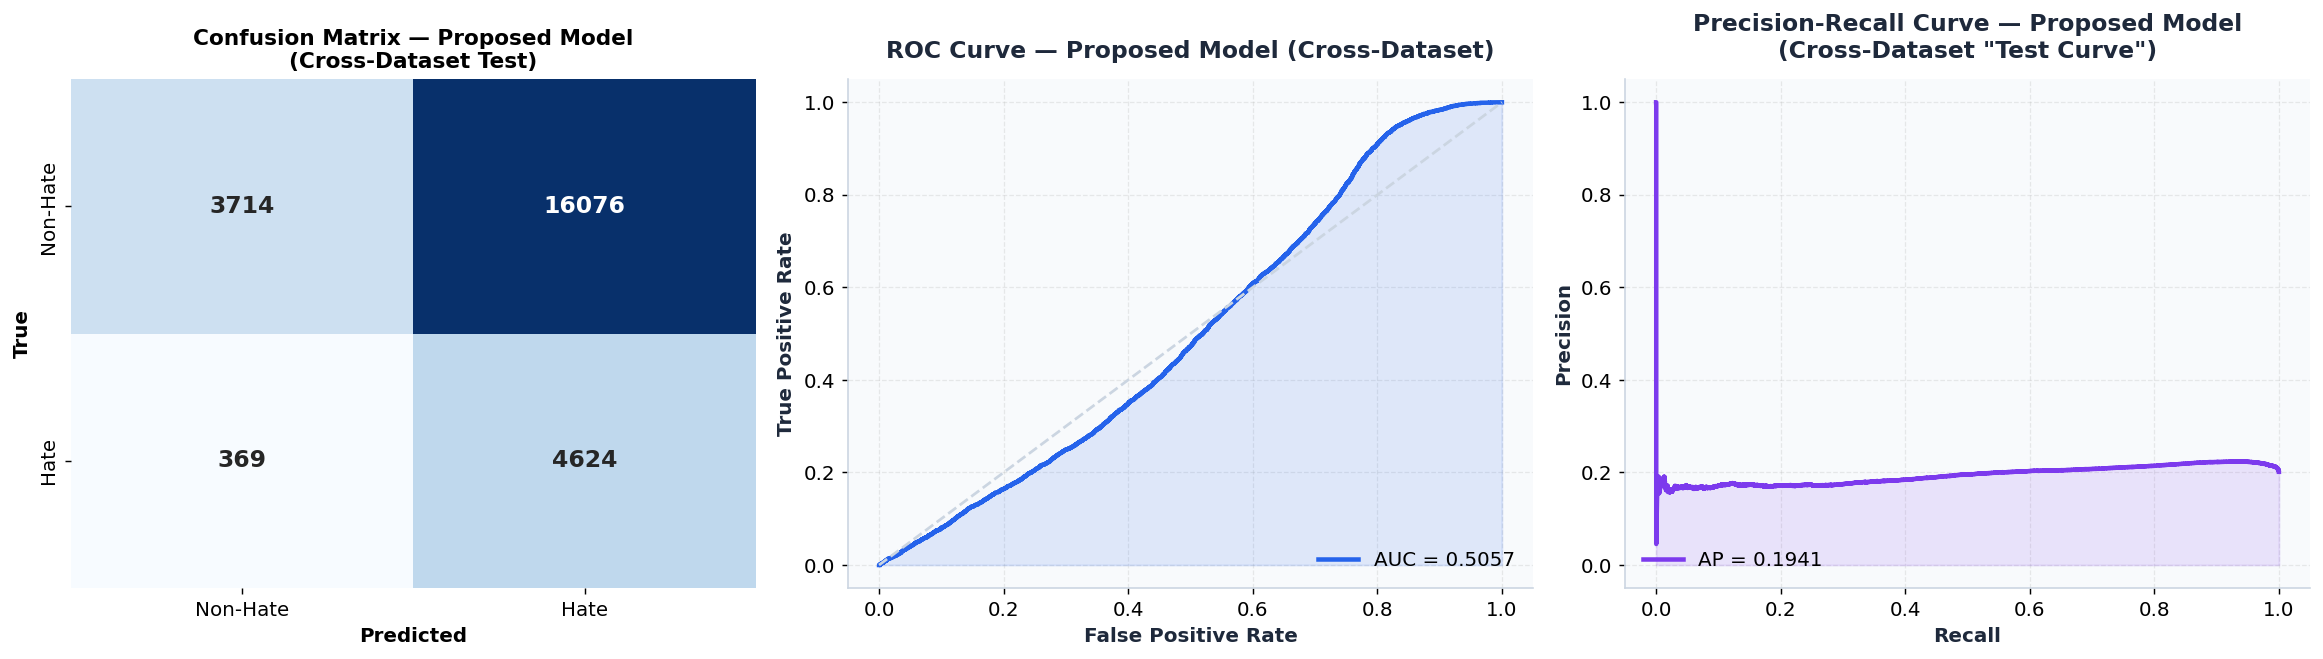

In [9]:
# ============================================================
# Teacher: cross-dataset (secondary) inference
# ============================================================
fusion_model.eval()
te_test_true, te_test_prob, te_test_fused = [], [], []
with torch.no_grad():
    for batch in tqdm(test_loader_ensemble, desc="Teacher cross-dataset inference"):
        bert_ids, bert_mask = batch["bert_ids"].to(device), batch["bert_mask"].to(device)
        xlmr_ids, xlmr_mask = batch["xlmr_ids"].to(device), batch["xlmr_mask"].to(device)
        deb_ids, deb_mask   = batch["deberta_ids"].to(device), batch["deberta_mask"].to(device)
        lb = batch["label"].to(device)
        hate_logits, _, fused = fusion_model(bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask)
        probs = torch.softmax(hate_logits, dim=1)
        te_test_true.extend(lb.cpu().numpy()); te_test_prob.extend(probs.cpu().numpy())
        te_test_fused.extend(fused.cpu().numpy())

te_test_true = np.array(te_test_true); te_test_prob = np.array(te_test_prob); te_test_fused = np.array(te_test_fused)
te_test_pred = (te_test_prob[:, 1] > te_best_t).astype(int)   # reuse threshold tuned on val

print("="*60); print("PROPOSED MODEL (Teacher) — CROSS-DATASET CLASSIFICATION REPORT"); print("="*60)
print(classification_report(te_test_true, te_test_pred, target_names=["Non-Hate", "Hate"]))
te_test_auc = roc_auc_score(te_test_true, te_test_prob[:, 1])
print(f"Cross-dataset Accuracy : {(te_test_true==te_test_pred).mean()*100:.2f}%")
print(f"Cross-dataset ROC AUC  : {te_test_auc:.4f}")

# ---- Confusion matrix + ROC + PR ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))

ax = axes[0]
cm = confusion_matrix(te_test_true, te_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Non-Hate','Hate'], yticklabels=['Non-Hate','Hate'], annot_kws={'fontweight':'bold','fontsize':13})
ax.set_title("Confusion Matrix — Proposed Model\n(Cross-Dataset Test)", fontsize=12, fontweight='bold')
ax.set_xlabel("Predicted", fontweight='bold'); ax.set_ylabel("True", fontweight='bold')

ax = axes[1]; style_axes(ax, "ROC Curve — Proposed Model (Cross-Dataset)", "False Positive Rate", "True Positive Rate")
fpr, tpr, _ = roc_curve(te_test_true, te_test_prob[:, 1])
ax.plot(fpr, tpr, color=PALETTE['primary'], lw=2.5, label=f"AUC = {te_test_auc:.4f}")
ax.plot([0,1],[0,1],'--', color=PALETTE['grid'], lw=1.5)
ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE['primary'])
ax.legend(loc='lower right', frameon=False)

ax = axes[2]; style_axes(ax, "Precision-Recall Curve — Proposed Model\n(Cross-Dataset \"Test Curve\")", "Recall", "Precision")
prec, rec, _ = precision_recall_curve(te_test_true, te_test_prob[:, 1])
ap = average_precision_score(te_test_true, te_test_prob[:, 1])
ax.plot(rec, prec, color=PALETTE['secondary'], lw=2.5, label=f"AP = {ap:.4f}")
ax.fill_between(rec, prec, alpha=0.12, color=PALETTE['secondary'])
ax.legend(loc='lower left', frameon=False)

plt.tight_layout(); savefig(fig, "teacher_crossdataset_eval"); plt.show()

## 9. Knowledge Distillation — Student (BERT)

Teacher: `DynamicFusionNet` (ensemble). Student: `bert-base-uncased`. The student learns from
both the hard labels **and** the teacher's soft probability distribution (KD loss).

In [10]:
# ============================================================
# Knowledge Distillation: Student training (resumable)
# ============================================================
student_train_ds = SingleInputDataset(train_texts, train_labels, bert_tokenizer, MAX_LEN)
student_val_ds   = SingleInputDataset(val_texts,   val_labels,   bert_tokenizer, MAX_LEN)
student_test_ds  = SingleInputDataset(test_texts,  test_labels,  bert_tokenizer, MAX_LEN)
student_train_ld = DataLoader(student_train_ds, batch_size=BATCH_SIZE, shuffle=True)
student_val_ld   = DataLoader(student_val_ds,   batch_size=BATCH_SIZE)
student_test_ld  = DataLoader(student_test_ds,  batch_size=BATCH_SIZE)

student_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_classes).to(device)
print(f"Student params: {sum(p.numel() for p in student_model.parameters())/1e6:.1f}M")

def kd_loss(student_logits, teacher_logits, hard_labels, alpha=0.5, temperature=4.0, weight=None):
    ce = F.cross_entropy(student_logits, hard_labels, weight=weight)
    student_soft = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_soft = F.softmax(teacher_logits / temperature, dim=-1)
    kl = F.kl_div(student_soft, teacher_soft, reduction='batchmean') * (temperature ** 2)
    return alpha * ce + (1 - alpha) * kl

# ---- Precompute teacher soft labels for the training set (ordered, no shuffle) ----
print("Generating teacher soft labels for KD...")
fusion_model.eval()
train_loader_ordered = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
teacher_train_logits = []
with torch.no_grad():
    for batch in tqdm(train_loader_ordered, desc="Teacher inference [train, for KD]"):
        bert_ids, bert_mask = batch["bert_ids"].to(device), batch["bert_mask"].to(device)
        xlmr_ids, xlmr_mask = batch["xlmr_ids"].to(device), batch["xlmr_mask"].to(device)
        deb_ids, deb_mask   = batch["deberta_ids"].to(device), batch["deberta_mask"].to(device)
        logits, _, _ = fusion_model(bert_ids, bert_mask, xlmr_ids, xlmr_mask, deb_ids, deb_mask)
        teacher_train_logits.append(logits.cpu())
teacher_train_logits = torch.cat(teacher_train_logits, dim=0)
print(f"Teacher logits shape: {teacher_train_logits.shape}")

class KDDataset(Dataset):
    def __init__(self, base_ds, teacher_logits):
        self.base_ds, self.teacher_logits = base_ds, teacher_logits
    def __len__(self): return len(self.base_ds)
    def __getitem__(self, idx):
        item = self.base_ds[idx]; item["teacher_logits"] = self.teacher_logits[idx]; return item

kd_train_ds = KDDataset(student_train_ds, teacher_train_logits)
kd_train_ld = DataLoader(kd_train_ds, batch_size=BATCH_SIZE, shuffle=True)

STUDENT_EPOCHS, STUDENT_PATIENCE = 5, 3
student_optimizer = torch.optim.AdamW(student_model.parameters(), lr=2e-5, weight_decay=0.01)
kd_total_steps = len(kd_train_ld) * STUDENT_EPOCHS
student_scheduler = get_linear_schedule_with_warmup(student_optimizer, num_warmup_steps=int(0.1*kd_total_steps), num_training_steps=kd_total_steps)

def student_train_step(model, batch):
    input_ids, attention_mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
    lb = batch["label"].to(device); teacher_logits = batch["teacher_logits"].to(device)
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = kd_loss(out.logits, teacher_logits, lb, alpha=0.5, temperature=4.0, weight=class_weights.to(device))
    student_optimizer.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    student_optimizer.step(); student_scheduler.step()
    preds = torch.argmax(out.logits, dim=1).cpu().numpy()
    return loss.item(), preds, lb.cpu().numpy()

def student_val_step(model, batch):
    input_ids, attention_mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
    lb = batch["label"].to(device)
    out = model(input_ids=input_ids, attention_mask=attention_mask)
    loss = F.cross_entropy(out.logits, lb)
    probs = torch.softmax(out.logits, dim=1); preds = torch.argmax(probs, dim=1)
    return preds.cpu().numpy(), lb.cpu().numpy(), probs.cpu().numpy(), loss.item()

# NOTE: kd_train_ld uses a DIFFERENT loss signature (needs teacher_logits), so we use a thin
# wrapper loop here instead of run_training_loop's generic val_loader path for TRAIN, but we
# still get full resume-safety via the same checkpoint mechanism.
student_history = run_training_loop(
    "Student-KD", student_model, student_optimizer, student_scheduler, kd_train_ld, student_val_ld,
    student_train_step, student_val_step, STUDENT_EPOCHS, STUDENT_PATIENCE,
    ckpt_path=os.path.join(CHECKPOINT_DIR, "student_ckpt.pt"),
    best_path=os.path.join(CHECKPOINT_DIR, "student_best.pt"),
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Student params: 109.5M
Generating teacher soft labels for KD...


Teacher inference [train, for KD]: 100%|██████████| 640/640 [07:21<00:00,  1.45it/s]


Teacher logits shape: torch.Size([20456, 2])
[Student-KD] No checkpoint found — starting fresh training.


...

[Student-KD] Epoch 3/5 | Train Acc 0.9472 Loss 0.1276 | Val Acc 0.9085 Loss 0.2609 | Gap 3.9%
   -> [Student-KD] new best saved (0.9085)


[Student-KD] Epoch 4/5 [Train]: 100%|██████████| 640/640 [06:53<00:00,  1.55it/s]


[Student-KD] Epoch 4/5 | Train Acc 0.9664 Loss 0.1189 | Val Acc 0.9081 Loss 0.2543 | Gap 5.8%
   -> [Student-KD] patience 1/3


[Student-KD] Epoch 5/5 [Train]: 100%|██████████| 640/640 [06:53<00:00,  1.55it/s]


[Student-KD] Epoch 5/5 | Train Acc 0.9742 Loss 0.1146 | Val Acc 0.9093 Loss 0.2570 | Gap 6.5%
   -> [Student-KD] new best saved (0.9093)


## 10. Student — In-Domain and Cross-Dataset Evaluation

Student in-domain eval: 100%|██████████| 160/160 [00:35<00:00,  4.53it/s]


STUDENT (KD-BERT) — IN-DOMAIN CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Hate       0.90      0.89      0.89      2201
        Hate       0.92      0.92      0.92      2913

    accuracy                           0.91      5114
   macro avg       0.91      0.91      0.91      5114
weighted avg       0.91      0.91      0.91      5114

Threshold Acc : 90.83% (t=0.40)  | AUC: 0.9666
ECE           : 0.0536


Student cross-dataset eval: 100%|██████████| 775/775 [02:51<00:00,  4.53it/s]



STUDENT (KD-BERT) — CROSS-DATASET CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Hate       0.91      0.21      0.34     19790
        Hate       0.23      0.92      0.36      4993

    accuracy                           0.35     24783
   macro avg       0.57      0.56      0.35     24783
weighted avg       0.77      0.35      0.34     24783

Cross-dataset Accuracy : 34.89% | AUC: 0.5047


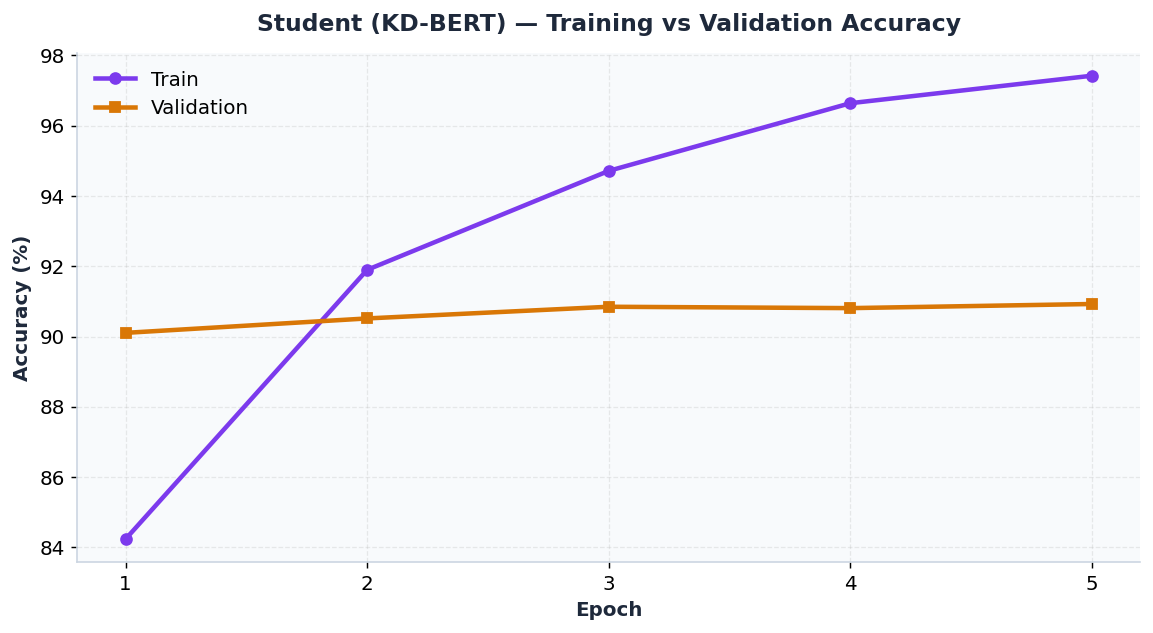


KNOWLEDGE DISTILLATION SUMMARY
Model                  Params(M)  In-Dom Acc   Cross Acc  Cross AUC
Teacher (Proposed)           529       89.50       33.64     0.5057
Student (KD-BERT)            109       90.83       34.89     0.5047
Compression ratio: 4.8x fewer parameters


In [11]:
# ============================================================
# Student: in-domain (val) + cross-dataset (test) inference
# ============================================================
def run_single_input_inference(model, loader, desc):
    model.eval()
    t_true, t_prob = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            input_ids, attention_mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
            lb = batch["label"].to(device)
            out = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(out.logits, dim=1)
            t_true.extend(lb.cpu().numpy()); t_prob.extend(probs.cpu().numpy())
    return np.array(t_true), np.array(t_prob)

st_val_true, st_val_prob = run_single_input_inference(student_model, student_val_ld, "Student in-domain eval")
st_best_t = max(np.arange(0.30, 0.70, 0.01), key=lambda t: f1_score(st_val_true, (st_val_prob[:,1] > t).astype(int)))
st_val_pred = (st_val_prob[:, 1] > st_best_t).astype(int)

print("="*60); print("STUDENT (KD-BERT) — IN-DOMAIN CLASSIFICATION REPORT"); print("="*60)
print(classification_report(st_val_true, st_val_pred, target_names=["Non-Hate", "Hate"]))
st_val_auc = roc_auc_score(st_val_true, st_val_prob[:, 1])
print(f"Threshold Acc : {(st_val_true==st_val_pred).mean()*100:.2f}% (t={st_best_t:.2f})  | AUC: {st_val_auc:.4f}")
st_ece, _, _ = compute_ece(st_val_prob, st_val_true)
print(f"ECE           : {st_ece:.4f}")

st_test_true, st_test_prob = run_single_input_inference(student_model, student_test_ld, "Student cross-dataset eval")
st_test_pred = (st_test_prob[:, 1] > st_best_t).astype(int)
print("\n" + "="*60); print("STUDENT (KD-BERT) — CROSS-DATASET CLASSIFICATION REPORT"); print("="*60)
print(classification_report(st_test_true, st_test_pred, target_names=["Non-Hate", "Hate"]))
st_test_auc = roc_auc_score(st_test_true, st_test_prob[:, 1])
print(f"Cross-dataset Accuracy : {(st_test_true==st_test_pred).mean()*100:.2f}% | AUC: {st_test_auc:.4f}")

# ---- Student training curves ----
fig, ax = plt.subplots(figsize=(9, 5))
ep = np.arange(1, len(student_history['train_acc']) + 1)
style_axes(ax, "Student (KD-BERT) — Training vs Validation Accuracy", "Epoch", "Accuracy (%)")
ax.plot(ep, np.array(student_history['train_acc'])*100, color=PALETTE['secondary'], lw=2.5, marker='o', label='Train')
ax.plot(ep, np.array(student_history['val_acc'])*100, color=PALETTE['amber'], lw=2.5, marker='s', label='Validation')
ax.legend(frameon=False); ax.set_xticks(ep)
plt.tight_layout(); savefig(fig, "student_training_curves"); plt.show()

# ---- Teacher vs Student summary ----
teacher_params = sum(p.numel() for p in fusion_model.parameters()) / 1e6
student_params = sum(p.numel() for p in student_model.parameters()) / 1e6
print("\n" + "="*60); print("KNOWLEDGE DISTILLATION SUMMARY"); print("="*60)
print(f"{'Model':<22}{'Params(M)':>10}{'In-Dom Acc':>12}{'Cross Acc':>12}{'Cross AUC':>11}")
print(f"{'Teacher (Proposed)':<22}{teacher_params:>10.0f}{(te_val_true==te_val_pred).mean()*100:>12.2f}{(te_test_true==te_test_pred).mean()*100:>12.2f}{te_test_auc:>11.4f}")
print(f"{'Student (KD-BERT)':<22}{student_params:>10.0f}{(st_val_true==st_val_pred).mean()*100:>12.2f}{(st_test_true==st_test_pred).mean()*100:>12.2f}{st_test_auc:>11.4f}")
print(f"Compression ratio: {teacher_params/student_params:.1f}x fewer parameters")

## 11. Single-Encoder Baselines (XLM-R, RoBERTa, DeBERTa)

Each baseline is a vanilla `AutoModelForSequenceClassification` fine-tuned the same way (same
splits, same class weights, same checkpoint/resume mechanism). They are evaluated in-domain and
cross-dataset, exactly like the proposed model, so the comparison is apples-to-apples.

In [12]:
# ============================================================
# Generic baseline pipeline (reused for every single-encoder model)
# ============================================================
BASELINE_CONFIGS = {
    "XLM-R (baseline)":   "xlm-roberta-base",
    "RoBERTa (baseline)": "roberta-base",
    "DeBERTa (baseline)": "microsoft/deberta-base",
}
BASELINE_EPOCHS, BASELINE_PATIENCE = 5, 3

def run_baseline_pipeline(name, hf_ckpt):
    safe = name.split()[0].lower().replace("-", "")
    print("\n" + "#"*70); print(f"# BASELINE: {name}  ({hf_ckpt})"); print("#"*70)

    tok = AutoTokenizer.from_pretrained(hf_ckpt)
    train_ds = SingleInputDataset(train_texts, train_labels, tok, MAX_LEN)
    val_ds   = SingleInputDataset(val_texts,   val_labels,   tok, MAX_LEN)
    test_ds  = SingleInputDataset(test_texts,  test_labels,  tok, MAX_LEN)
    train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_ld   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = AutoModelForSequenceClassification.from_pretrained(hf_ckpt, num_labels=num_classes).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    total_steps = len(train_ld) * BASELINE_EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    wts = class_weights.to(device)

    def train_step(m, batch):
        input_ids, attention_mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        lb = batch["label"].to(device)
        out = m(input_ids=input_ids, attention_mask=attention_mask)
        loss = F.cross_entropy(out.logits, lb, weight=wts)
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        return loss.item(), torch.argmax(out.logits, dim=1).cpu().numpy(), lb.cpu().numpy()

    def val_step(m, batch):
        input_ids, attention_mask = batch["input_ids"].to(device), batch["attention_mask"].to(device)
        lb = batch["label"].to(device)
        out = m(input_ids=input_ids, attention_mask=attention_mask)
        loss = F.cross_entropy(out.logits, lb)
        probs = torch.softmax(out.logits, dim=1); preds = torch.argmax(probs, dim=1)
        return preds.cpu().numpy(), lb.cpu().numpy(), probs.cpu().numpy(), loss.item()

    history = run_training_loop(
        name, model, optimizer, scheduler, train_ld, val_ld, train_step, val_step,
        BASELINE_EPOCHS, BASELINE_PATIENCE,
        ckpt_path=os.path.join(CHECKPOINT_DIR, f"{safe}_ckpt.pt"),
        best_path=os.path.join(CHECKPOINT_DIR, f"{safe}_best.pt"),
    )

    val_true, val_prob = run_single_input_inference(model, val_ld, f"{name} in-domain eval")
    best_t = max(np.arange(0.30, 0.70, 0.01), key=lambda t: f1_score(val_true, (val_prob[:,1] > t).astype(int)))
    val_pred = (val_prob[:, 1] > best_t).astype(int)

    test_true, test_prob = run_single_input_inference(model, test_ld, f"{name} cross-dataset eval")
    test_pred = (test_prob[:, 1] > best_t).astype(int)

    print(f"\n[{name}] In-domain Acc: {(val_true==val_pred).mean()*100:.2f}% | "
          f"Cross-dataset Acc: {(test_true==test_pred).mean()*100:.2f}% | "
          f"Cross-dataset AUC: {roc_auc_score(test_true, test_prob[:,1]):.4f}")

    params_m = sum(p.numel() for p in model.parameters()) / 1e6
    return {
        "name": name, "model": model, "tokenizer": tok, "history": history, "params_m": params_m,
        "val_true": val_true, "val_pred": val_pred, "val_prob": val_prob,
        "test_true": test_true, "test_pred": test_pred, "test_prob": test_prob,
        "threshold": best_t,
    }

baseline_results = {}
for name, ckpt in BASELINE_CONFIGS.items():
    baseline_results[name] = run_baseline_pipeline(name, ckpt)
    torch.cuda.empty_cache(); gc.collect()

print("\nAll baselines trained/evaluated.")


######################################################################
# BASELINE: XLM-R (baseline)  (xlm-roberta-base)
######################################################################


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[XLM-R (baseline)] No checkpoint found — starting fresh training.


[XLM-R (baseline)] Epoch 1/5 [Train]: 100%|██████████| 640/640 [07:36<00:00,  1.40it/s]


...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaForSequenceClassification LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[DeBERTa (baseline)] No checkpoint found — starting fresh training.


[DeBERTa (baseline)] Epoch 1/5 [Train]:   0%|          | 0/640 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 12.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 18.81 MiB is free. Including non-PyTorch memory, this process has 14.54 GiB memory in use. Of the allocated memory 14.22 GiB is allocated by PyTorch, and 187.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## 12. Cross-Model Comparison (Cross-Dataset Test Set)

Proposed model, KD-student, and all 3 baselines compared on the **same out-of-domain test set**
— multi-curve ROC, confusion-matrix grid, and metric bar charts.

In [ ]:
# ============================================================
# Consolidated comparison across all 5 models
# ============================================================
all_models = {
    "Proposed (DynamicFusionNet)": {"true": te_test_true, "pred": te_test_pred, "prob": te_test_prob, "params": teacher_params},
    "Student (KD-BERT)":           {"true": st_test_true, "pred": st_test_pred, "prob": st_test_prob, "params": student_params},
}
for name, res in baseline_results.items():
    all_models[name] = {"true": res["test_true"], "pred": res["test_pred"], "prob": res["test_prob"], "params": res["params_m"]}

# ---- Multi-curve ROC ----
fig, ax = plt.subplots(figsize=(8, 7))
style_axes(ax, "ROC Curve Comparison — Cross-Dataset Test", "False Positive Rate", "True Positive Rate")
for name, res in all_models.items():
    fpr, tpr, _ = roc_curve(res["true"], res["prob"][:, 1])
    auc_v = roc_auc_score(res["true"], res["prob"][:, 1])
    ax.plot(fpr, tpr, lw=2.5, color=MODEL_COLORS[name], label=f"{name} (AUC={auc_v:.3f})")
ax.plot([0,1],[0,1],'--', color=PALETTE['grid'], lw=1.5)
ax.legend(loc='lower right', fontsize=8.5, frameon=False)
plt.tight_layout(); savefig(fig, "all_models_roc_comparison"); plt.show()

# ---- Confusion matrix grid ----
fig, axes = plt.subplots(1, 5, figsize=(22, 4.2))
for ax, (name, res) in zip(axes, all_models.items()):
    cm = confusion_matrix(res["true"], res["pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Non-Hate','Hate'], yticklabels=['Non-Hate','Hate'], annot_kws={'fontweight':'bold'})
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=9); ax.set_ylabel("True", fontsize=9)
plt.tight_layout(); savefig(fig, "all_models_confusion_matrix_grid"); plt.show()

# ---- Metric comparison bars ----
metrics_rows = []
for name, res in all_models.items():
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(res["true"], res["pred"]) * 100,
        "Precision": precision_score(res["true"], res["pred"]) * 100,
        "Recall": recall_score(res["true"], res["pred"]) * 100,
        "F1": f1_score(res["true"], res["pred"]) * 100,
        "AUC": roc_auc_score(res["true"], res["prob"][:, 1]),
        "Params(M)": res["params"],
    })
comparison_df = pd.DataFrame(metrics_rows).sort_values("F1", ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5.5))
style_axes(ax, "Cross-Dataset Performance Comparison", "Model", "Score (%)")
x = np.arange(len(comparison_df)); width = 0.2
for i, metric in enumerate(["Accuracy", "Precision", "Recall", "F1"]):
    ax.bar(x + (i-1.5)*width, comparison_df[metric], width, label=metric, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(comparison_df["Model"], rotation=15, ha='right', fontsize=9)
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18))
plt.tight_layout(); savefig(fig, "all_models_metric_bars"); plt.show()

# Identify best baseline (excluding proposed + student) by cross-dataset F1
best_baseline_name = comparison_df[comparison_df["Model"].isin(baseline_results.keys())].iloc[0]["Model"]
print(f"\nBest-performing baseline on cross-dataset test: {best_baseline_name}")

## 13. Statistical Significance — McNemar's Test + Bootstrap Paired t-Test

McNemar's test compares the proposed model's per-sample correctness against the **best baseline**
on the cross-dataset test set. The bootstrap paired t-test resamples the test set 1,000 times and
compares accuracy distributions, giving a robust significance estimate beyond a single point score.

In [ ]:
# ============================================================
# McNemar's test + bootstrap paired t-test (Proposed vs Best Baseline)
# ============================================================
best_res = baseline_results[best_baseline_name]
proposed_true, proposed_pred = te_test_true, te_test_pred
baseline_true, baseline_pred = best_res["test_true"], best_res["test_pred"]
assert len(proposed_true) == len(baseline_true), "Test sets must align — both come from df_test."

def mcnemar_test(true, pred_a, pred_b, correction=True):
    correct_a = (pred_a == true); correct_b = (pred_b == true)
    n01 = int(np.sum(correct_a & ~correct_b))   # proposed correct, baseline wrong
    n10 = int(np.sum(~correct_a & correct_b))   # proposed wrong, baseline correct
    if correction:
        stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10) if (n01 + n10) > 0 else 0.0
    else:
        stat = (n01 - n10) ** 2 / (n01 + n10) if (n01 + n10) > 0 else 0.0
    p = 1 - chi2.cdf(stat, df=1)
    return stat, p, n01, n10

stat, p_val, n01, n10 = mcnemar_test(proposed_true, proposed_pred, baseline_pred)
print("="*60); print(f"McNEMAR'S TEST — Proposed vs {best_baseline_name}"); print("="*60)
print(f"Proposed-correct/Baseline-wrong : {n01}")
print(f"Proposed-wrong/Baseline-correct : {n10}")
print(f"Chi-square statistic            : {stat:.4f}")
print(f"p-value                         : {p_val:.6f}")
print(f"Statistically significant (a=0.05): {'YES' if p_val < 0.05 else 'NO'}")

# ---- Contingency heatmap ----
both_correct = int(np.sum((proposed_pred==proposed_true)&(baseline_pred==baseline_true)))
both_wrong   = int(np.sum((proposed_pred!=proposed_true)&(baseline_pred!=baseline_true)))
contingency = np.array([[both_correct, n01], [n10, both_wrong]])
fig, ax = plt.subplots(figsize=(6, 5.5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=[f'{best_baseline_name}\nCorrect', f'{best_baseline_name}\nWrong'],
            yticklabels=['Proposed\nCorrect', 'Proposed\nWrong'], annot_kws={'fontweight':'bold','fontsize':13})
ax.set_title(f"McNemar Contingency Table\n(p={p_val:.4f})", fontsize=12, fontweight='bold')
plt.tight_layout(); savefig(fig, "mcnemar_contingency"); plt.show()

# ---- Bootstrap paired t-test on accuracy distributions ----
N_BOOT = 1000
rng = np.random.default_rng(SEED)
n_samples = len(proposed_true)
proposed_accs, baseline_accs = [], []
for _ in range(N_BOOT):
    idx = rng.integers(0, n_samples, n_samples)
    proposed_accs.append((proposed_pred[idx] == proposed_true[idx]).mean())
    baseline_accs.append((baseline_pred[idx] == baseline_true[idx]).mean())
proposed_accs, baseline_accs = np.array(proposed_accs), np.array(baseline_accs)

t_stat, t_p = ttest_rel(proposed_accs, baseline_accs)
print("\n" + "="*60); print(f"BOOTSTRAP PAIRED t-TEST ({N_BOOT} resamples)"); print("="*60)
print(f"Proposed mean accuracy : {proposed_accs.mean()*100:.2f}% (+/- {proposed_accs.std()*100:.2f})")
print(f"Baseline mean accuracy : {baseline_accs.mean()*100:.2f}% (+/- {baseline_accs.std()*100:.2f})")
print(f"t-statistic            : {t_stat:.4f}")
print(f"p-value                : {t_p:.6f}")
print(f"Statistically significant (a=0.05): {'YES' if t_p < 0.05 else 'NO'}")

fig, ax = plt.subplots(figsize=(8, 5.5))
style_axes(ax, f"Bootstrap Accuracy Distributions ({N_BOOT} resamples)", "Model", "Accuracy")
box_data = [proposed_accs, baseline_accs]
bp = ax.violinplot(box_data, showmeans=True, showextrema=True)
for body, col in zip(bp['bodies'], [PALETTE['primary'], MODEL_COLORS[best_baseline_name]]):
    body.set_facecolor(col); body.set_alpha(0.55)
ax.set_xticks([1, 2]); ax.set_xticklabels(["Proposed\n(DynamicFusionNet)", best_baseline_name])
ax.text(0.5, 0.02, f"paired t-test p = {t_p:.4f}", transform=ax.transAxes, ha='center',
        fontsize=10, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', edgecolor=PALETTE['grid']))
plt.tight_layout(); savefig(fig, "bootstrap_ttest_violin"); plt.show()

## 14. Embedding Space Visualization (UMAP)

Projects the proposed model's fused 768-d representation (cross-dataset test set) into 2D,
colored by true class and by correct/incorrect prediction — useful for showing how well the
fused embedding space separates hate vs non-hate even on unseen, out-of-domain data.

In [ ]:
# ============================================================
# UMAP projection of teacher fused embeddings (cross-dataset test set)
# ============================================================
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn"], check=True)
    import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=SEED)
embedding_2d = reducer.fit_transform(te_test_fused)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

ax = axes[0]; style_axes(ax, "UMAP — Colored by True Label\n(Proposed Model, Cross-Dataset Test)", "UMAP-1", "UMAP-2")
for cls, label, col in [(0, 'Non-Hate', PALETTE['accent']), (1, 'Hate', PALETTE['danger'])]:
    mask = te_test_true == cls
    ax.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], s=8, alpha=0.55, color=col, label=label, edgecolors='none')
ax.legend(frameon=False, markerscale=2)

ax = axes[1]; style_axes(ax, "UMAP — Correct vs Misclassified\n(Proposed Model, Cross-Dataset Test)", "UMAP-1", "UMAP-2")
correct_mask = te_test_pred == te_test_true
ax.scatter(embedding_2d[correct_mask, 0], embedding_2d[correct_mask, 1], s=8, alpha=0.35,
           color=PALETTE['primary'], label='Correct', edgecolors='none')
ax.scatter(embedding_2d[~correct_mask, 0], embedding_2d[~correct_mask, 1], s=14, alpha=0.85,
           color=PALETTE['danger'], label='Misclassified', edgecolors='none')
ax.legend(frameon=False, markerscale=2)

plt.tight_layout(); savefig(fig, "umap_embedding_visualization"); plt.show()

## 15. Latency & Computational Complexity Analysis

Inference latency, throughput, parameter count, and model size for every model — plus an
accuracy-vs-latency **efficiency frontier** bubble chart (bubble size = parameter count), which is
the kind of figure expected in a 2026-style efficiency/complexity analysis.

In [ ]:
# ============================================================
# Latency / throughput / complexity benchmark
# ============================================================
def measure_latency(model, sample_batch, n_warmup=5, n_runs=30, multi_input=False):
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            if multi_input:
                model(sample_batch["bert_ids"], sample_batch["bert_mask"], sample_batch["xlmr_ids"],
                      sample_batch["xlmr_mask"], sample_batch["deberta_ids"], sample_batch["deberta_mask"])
            else:
                model(input_ids=sample_batch["input_ids"], attention_mask=sample_batch["attention_mask"])
        if torch.cuda.is_available(): torch.cuda.synchronize()
        start = time.time()
        for _ in range(n_runs):
            if multi_input:
                model(sample_batch["bert_ids"], sample_batch["bert_mask"], sample_batch["xlmr_ids"],
                      sample_batch["xlmr_mask"], sample_batch["deberta_ids"], sample_batch["deberta_mask"])
            else:
                model(input_ids=sample_batch["input_ids"], attention_mask=sample_batch["attention_mask"])
        if torch.cuda.is_available(): torch.cuda.synchronize()
        elapsed = time.time() - start
    batch_size = sample_batch["label"].size(0) if "label" in sample_batch else sample_batch["bert_ids"].size(0)
    ms_per_batch  = (elapsed / n_runs) * 1000
    ms_per_sample = ms_per_batch / batch_size
    throughput    = batch_size / (elapsed / n_runs)
    return ms_per_sample, throughput

def model_size_mb(model):
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)

# sample batches
ensemble_batch = next(iter(DataLoader(val_dataset, batch_size=16)))
ensemble_batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in ensemble_batch.items()}
single_batch = next(iter(DataLoader(student_val_ds, batch_size=16)))
single_batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in single_batch.items()}

complexity_rows = []
ms, thr = measure_latency(fusion_model, ensemble_batch, multi_input=True)
complexity_rows.append({"Model": "Proposed (DynamicFusionNet)", "Params(M)": teacher_params,
                         "Size(MB)": model_size_mb(fusion_model), "Latency(ms/sample)": ms, "Throughput(samples/s)": thr})

ms, thr = measure_latency(student_model, single_batch, multi_input=False)
complexity_rows.append({"Model": "Student (KD-BERT)", "Params(M)": student_params,
                         "Size(MB)": model_size_mb(student_model), "Latency(ms/sample)": ms, "Throughput(samples/s)": thr})

for name, res in baseline_results.items():
    b = next(iter(DataLoader(SingleInputDataset(val_texts, val_labels, res["tokenizer"], MAX_LEN), batch_size=16)))
    b = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in b.items()}
    ms, thr = measure_latency(res["model"], b, multi_input=False)
    complexity_rows.append({"Model": name, "Params(M)": res["params_m"],
                             "Size(MB)": model_size_mb(res["model"]), "Latency(ms/sample)": ms, "Throughput(samples/s)": thr})

complexity_df = pd.DataFrame(complexity_rows)
complexity_df = complexity_df.merge(comparison_df[["Model", "Accuracy", "F1", "AUC"]], on="Model", how="left")
print(complexity_df.to_string(index=False))

# ---- Efficiency frontier bubble chart ----
fig, ax = plt.subplots(figsize=(9, 7))
style_axes(ax, "Accuracy vs Latency Efficiency Frontier\n(bubble size = parameter count)", "Latency (ms/sample)", "Cross-Dataset Accuracy (%)")
for _, row in complexity_df.iterrows():
    ax.scatter(row["Latency(ms/sample)"], row["Accuracy"], s=row["Params(M)"]*6, alpha=0.65,
               color=MODEL_COLORS.get(row["Model"], PALETTE['dark']), edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(row["Model"], (row["Latency(ms/sample)"], row["Accuracy"]),
                xytext=(6, 6), textcoords='offset points', fontsize=8.5, fontweight='bold', color=PALETTE['dark'])
plt.tight_layout(); savefig(fig, "efficiency_frontier_bubble"); plt.show()

# ---- Latency bar chart ----
fig, ax = plt.subplots(figsize=(10, 5))
style_axes(ax, "Inference Latency Comparison", "Model", "Latency (ms / sample)")
colors = [MODEL_COLORS.get(m, PALETTE['dark']) for m in complexity_df["Model"]]
ax.bar(complexity_df["Model"], complexity_df["Latency(ms/sample)"], color=colors, alpha=0.9, width=0.55, zorder=3)
ax.set_xticklabels(complexity_df["Model"], rotation=15, ha='right', fontsize=9)
plt.tight_layout(); savefig(fig, "latency_comparison_bar"); plt.show()

## 16. Final Consolidated Results Table

All metrics (in-domain + cross-dataset + complexity + significance) in one place — export-ready
for the paper's results table.

In [ ]:
# ============================================================
# Final consolidated results table
# ============================================================
final_rows = []
in_domain_map = {
    "Proposed (DynamicFusionNet)": (te_val_true, te_val_pred, te_val_prob),
    "Student (KD-BERT)":           (st_val_true, st_val_pred, st_val_prob),
}
for name, res in baseline_results.items():
    in_domain_map[name] = (res["val_true"], res["val_pred"], res["val_prob"])

for _, row in complexity_df.iterrows():
    name = row["Model"]
    v_true, v_pred, v_prob = in_domain_map[name]
    final_rows.append({
        "Model": name,
        "Params(M)": round(row["Params(M)"], 1),
        "Size(MB)": round(row["Size(MB)"], 1),
        "In-Domain Acc(%)": round(accuracy_score(v_true, v_pred) * 100, 2),
        "In-Domain AUC": round(roc_auc_score(v_true, v_prob[:, 1]), 4),
        "Cross-Dataset Acc(%)": round(row["Accuracy"], 2),
        "Cross-Dataset F1(%)": round(row["F1"], 2),
        "Cross-Dataset AUC": round(row["AUC"], 4),
        "Latency(ms/sample)": round(row["Latency(ms/sample)"], 3),
        "Throughput(samples/s)": round(row["Throughput(samples/s)"], 1),
    })

final_results_df = pd.DataFrame(final_rows).sort_values("Cross-Dataset F1(%)", ascending=False).reset_index(drop=True)
print("="*100)
print("FINAL CONSOLIDATED RESULTS")
print("="*100)
print(final_results_df.to_string(index=False))

print(f"\nMcNemar's test (Proposed vs {best_baseline_name}): p = {p_val:.6f} -> "
      f"{'significant' if p_val < 0.05 else 'not significant'} at alpha=0.05")
print(f"Bootstrap paired t-test ({N_BOOT} resamples): p = {t_p:.6f} -> "
      f"{'significant' if t_p < 0.05 else 'not significant'} at alpha=0.05")

out_path = "/kaggle/working/final_results_summary.csv"
final_results_df.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")
print(f"All figures saved to: {FIGURE_DIR}")